---
# Week 4 — Advanced Model Training


### Step 1: Import Libraries for Week 4


In [50]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
import time

print('Libraries loaded for Week 4 ✅')


Libraries loaded for Week 4 ✅


### Step 2: Model 3 — Random Forest
An ensemble of many decision trees. Each tree is slightly different, and they vote on the final prediction.


Model   : Random Forest
Accuracy: 86.11%

              precision    recall  f1-score   support

       green       0.93      0.82      0.87        65
      yellow       0.82      0.77      0.79        64
      orange       0.85      0.89      0.87        63
         red       0.86      0.98      0.91        60

    accuracy                           0.86       252
   macro avg       0.86      0.86      0.86       252
weighted avg       0.86      0.86      0.86       252



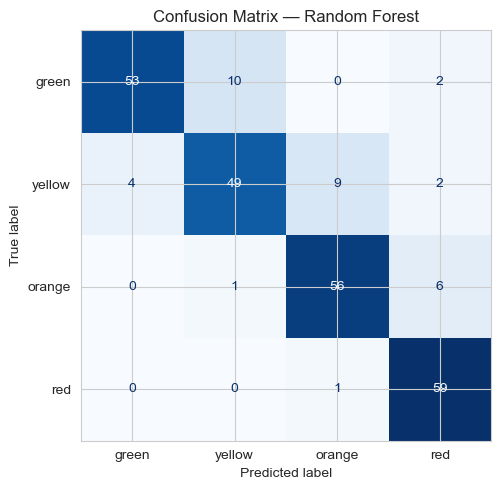

In [52]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

evaluate_model('Random Forest', y_test, rf_preds)


### Step 3: Model 4 — Gradient Boosting
Builds trees sequentially, where each tree corrects the mistakes of the previous ones.


Model   : Gradient Boosting
Accuracy: 90.08%

              precision    recall  f1-score   support

       green       0.90      0.88      0.89        65
      yellow       0.89      0.84      0.86        64
      orange       0.88      0.92      0.90        63
         red       0.94      0.97      0.95        60

    accuracy                           0.90       252
   macro avg       0.90      0.90      0.90       252
weighted avg       0.90      0.90      0.90       252



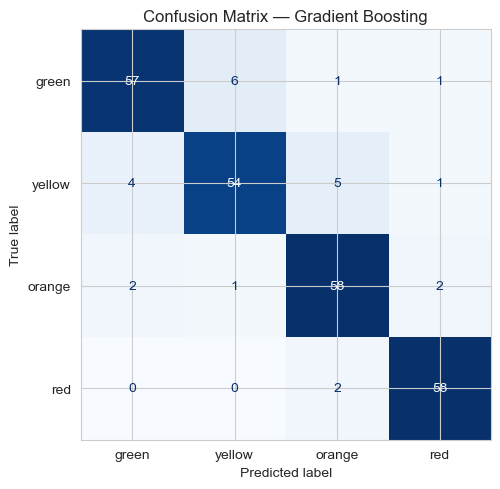

In [54]:
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)

gb_preds = gb_model.predict(X_test)

evaluate_model('Gradient Boosting', y_test, gb_preds)


### Step 4: Cross-Validation
Test each model on 5 different splits of the data to ensure it generalizes well.


In [56]:
print('Cross-Validation Results (5-Fold):')
print('=' * 60)

models_cv = {
    'Logistic Regression': lr_model,
    'Decision Tree'      : dt_model,
    'Random Forest'      : rf_model,
    'Gradient Boosting'  : gb_model,
}

cv_results = {}

for model_name, model in models_cv.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_results[model_name] = {
        'mean'  : cv_scores.mean(),
        'std'   : cv_scores.std(),
        'scores': cv_scores
    }
    print(f'{model_name:20} | Mean: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}')
    print(f'{"":20} | Fold Scores: {[f"{s:.4f}" for s in cv_scores]}')
    print()


Cross-Validation Results (5-Fold):
Logistic Regression  | Mean: 0.6792 | Std: 0.0361
                     | Fold Scores: ['0.6965', '0.6517', '0.6965', '0.7264', '0.6250']

Decision Tree        | Mean: 0.7699 | Std: 0.0147
                     | Fold Scores: ['0.7811', '0.7711', '0.7413', '0.7761', '0.7800']

Random Forest        | Mean: 0.8645 | Std: 0.0088
                     | Fold Scores: ['0.8607', '0.8706', '0.8657', '0.8756', '0.8500']

Gradient Boosting    | Mean: 0.8705 | Std: 0.0205
                     | Fold Scores: ['0.8756', '0.8806', '0.8856', '0.8806', '0.8300']



### Step 5: Hyperparameter Tuning — Random Forest
Use GridSearchCV to find the best combination of parameters.


Tuning Random Forest - this may take 30-60 seconds...
Best parameters for Random Forest: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 50}
Best cross-validation score: 0.8645
Time taken: 16.24 seconds

Model   : Random Forest (Tuned)
Accuracy: 88.89%

              precision    recall  f1-score   support

       green       0.90      0.83      0.86        65
      yellow       0.82      0.80      0.81        64
      orange       0.91      0.95      0.93        63
         red       0.92      0.98      0.95        60

    accuracy                           0.89       252
   macro avg       0.89      0.89      0.89       252
weighted avg       0.89      0.89      0.89       252



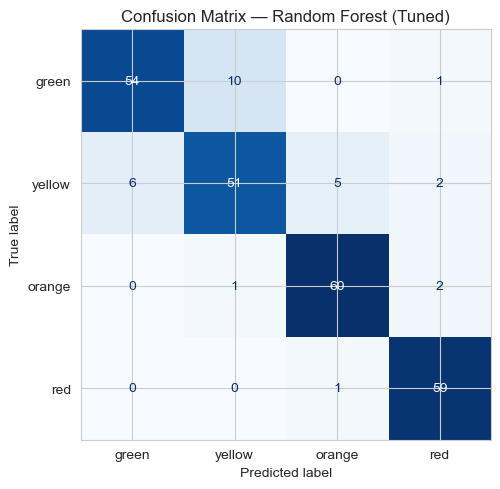

In [58]:
print('Tuning Random Forest - this may take 30-60 seconds...')
print('=' * 60)

param_grid_rf = {
    'n_estimators'    : [50, 100, 150],
    'max_depth'       : [5, 10, 15],
    'min_samples_split': [2, 5],
}

grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

start_time = time.time()
grid_search_rf.fit(X_train, y_train)
elapsed = time.time() - start_time

print(f'Best parameters for Random Forest: {grid_search_rf.best_params_}')
print(f'Best cross-validation score: {grid_search_rf.best_score_:.4f}')
print(f'Time taken: {elapsed:.2f} seconds\n')

best_rf_preds = grid_search_rf.predict(X_test)
evaluate_model('Random Forest (Tuned)', y_test, best_rf_preds)


### Step 6: Hyperparameter Tuning — Gradient Boosting


Tuning Gradient Boosting - this may take 30-60 seconds...
Best parameters for Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 150}
Best cross-validation score: 0.8785
Time taken: 73.38 seconds

Model   : Gradient Boosting (Tuned)
Accuracy: 89.29%

              precision    recall  f1-score   support

       green       0.88      0.88      0.88        65
      yellow       0.90      0.81      0.85        64
      orange       0.88      0.92      0.90        63
         red       0.92      0.97      0.94        60

    accuracy                           0.89       252
   macro avg       0.89      0.89      0.89       252
weighted avg       0.89      0.89      0.89       252



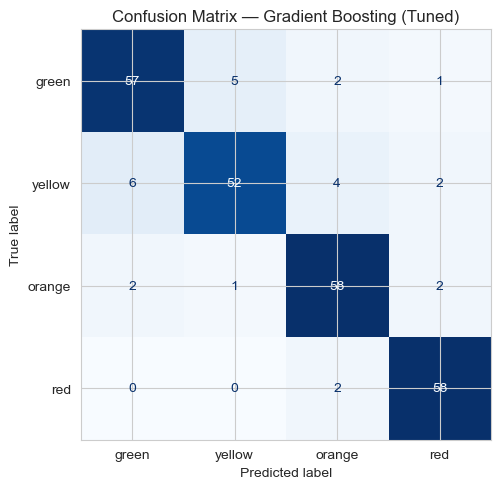

In [60]:
print('Tuning Gradient Boosting - this may take 30-60 seconds...')
print('=' * 60)

param_grid_gb = {
    'n_estimators' : [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth'    : [3, 5, 7],
}

grid_search_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

start_time = time.time()
grid_search_gb.fit(X_train, y_train)
elapsed = time.time() - start_time

print(f'Best parameters for Gradient Boosting: {grid_search_gb.best_params_}')
print(f'Best cross-validation score: {grid_search_gb.best_score_:.4f}')
print(f'Time taken: {elapsed:.2f} seconds\n')

best_gb_preds = grid_search_gb.predict(X_test)
evaluate_model('Gradient Boosting (Tuned)', y_test, best_gb_preds)


### Step 7: Feature Importance — Random Forest vs Gradient Boosting


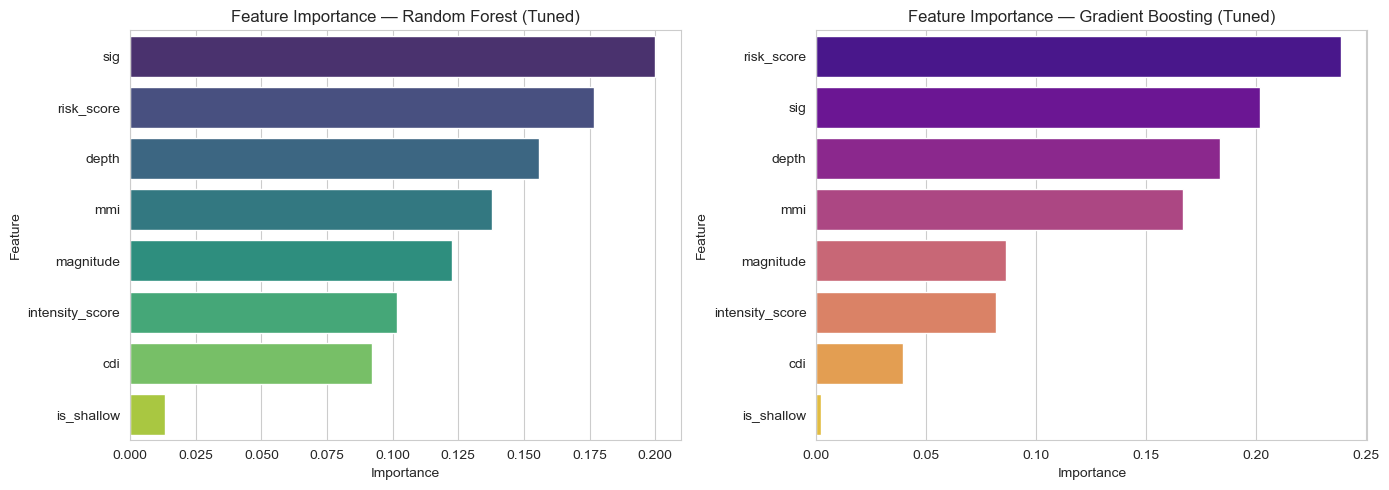

Random Forest Feature Importance:
        Feature  Importance
            sig    0.199921
     risk_score    0.176640
          depth    0.155812
            mmi    0.137759
      magnitude    0.122728
intensity_score    0.101803
            cdi    0.091974
     is_shallow    0.013363

Gradient Boosting Feature Importance:
        Feature  Importance
     risk_score    0.238609
            sig    0.201668
          depth    0.183357
            mmi    0.166507
      magnitude    0.086322
intensity_score    0.081844
            cdi    0.039449
     is_shallow    0.002245


In [62]:
feature_cols = ['magnitude', 'depth', 'cdi', 'mmi', 'sig',
                'is_shallow', 'intensity_score', 'risk_score']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest Feature Importance
rf_feat_imp = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': grid_search_rf.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(data=rf_feat_imp, x='Importance', y='Feature', palette='viridis', ax=ax1)
ax1.set_title('Feature Importance — Random Forest (Tuned)')

# Gradient Boosting Feature Importance
gb_feat_imp = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': grid_search_gb.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=False)

sns.barplot(data=gb_feat_imp, x='Importance', y='Feature', palette='plasma', ax=ax2)
ax2.set_title('Feature Importance — Gradient Boosting (Tuned)')

plt.tight_layout()
plt.show()

print('Random Forest Feature Importance:')
print(rf_feat_imp.to_string(index=False))
print('\nGradient Boosting Feature Importance:')
print(gb_feat_imp.to_string(index=False))


### Step 8: Final Model Comparison — All Models


FINAL MODEL COMPARISON — ALL MODELS
                    Model  Test Accuracy (%)
        Gradient Boosting              90.08
Gradient Boosting (Tuned)              89.29
    Random Forest (Tuned)              88.89
            Random Forest              86.11
            Decision Tree              78.57
      Logistic Regression              59.13



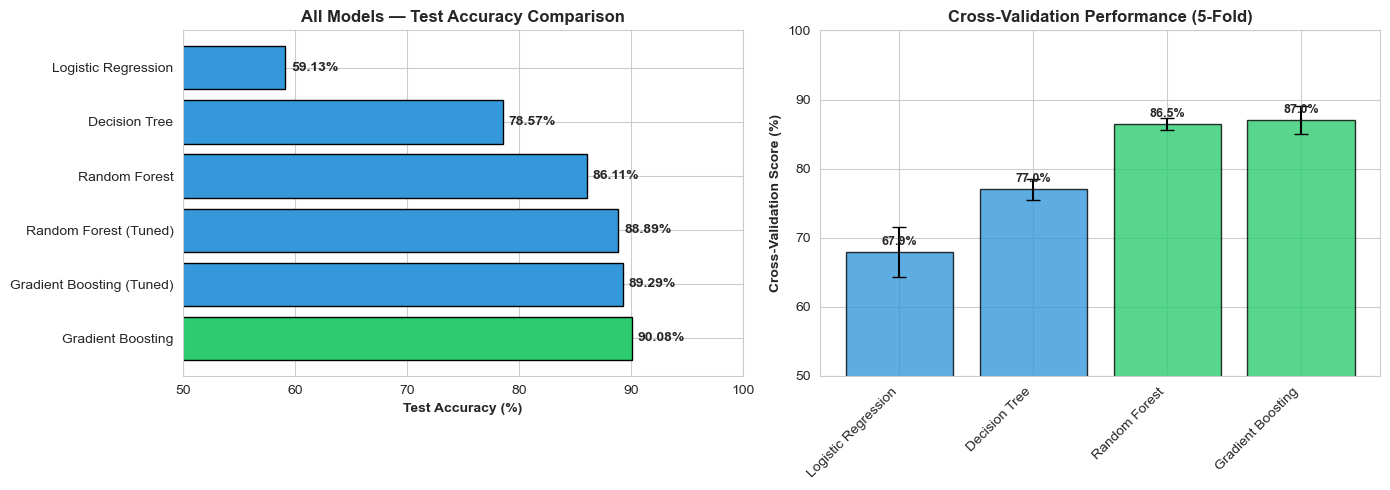

In [64]:
print('FINAL MODEL COMPARISON — ALL MODELS')
print('=' * 80)

final_comparison = pd.DataFrame({
    'Model'             : list(results.keys()),
    'Test Accuracy (%)' : list(results.values())
}).sort_values('Test Accuracy (%)', ascending=False)

print(final_comparison.to_string(index=False))
print()

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_bar = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(final_comparison))]
axes[0].barh(final_comparison['Model'], final_comparison['Test Accuracy (%)'],
             color=colors_bar, edgecolor='black')
axes[0].set_xlabel('Test Accuracy (%)', fontweight='bold')
axes[0].set_title('All Models — Test Accuracy Comparison', fontweight='bold')
axes[0].set_xlim(50, 100)

for i, v in enumerate(final_comparison['Test Accuracy (%)']):
    axes[0].text(v + 0.5, i, f'{v:.2f}%', va='center', fontweight='bold')

# Cross-validation comparison
baseline_models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting']
cv_means = [cv_results[m]['mean'] * 100 for m in baseline_models]
cv_stds  = [cv_results[m]['std']  * 100 for m in baseline_models]

axes[1].bar(range(len(baseline_models)), cv_means, yerr=cv_stds, capsize=5,
            color=['#3498db', '#3498db', '#2ecc71', '#2ecc71'],
            edgecolor='black', alpha=0.8)
axes[1].set_xticks(range(len(baseline_models)))
axes[1].set_xticklabels(baseline_models, rotation=45, ha='right')
axes[1].set_ylabel('Cross-Validation Score (%)', fontweight='bold')
axes[1].set_title('Cross-Validation Performance (5-Fold)', fontweight='bold')
axes[1].set_ylim(50, 100)

for i, (mean, std) in enumerate(zip(cv_means, cv_stds)):
    axes[1].text(i, mean + 1, f'{mean:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()
